In [5]:
import numpy as np
import pandas as pd
import your
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import sys
import matplotlib as mpl
from matplotlib import colors
from scipy.optimize import curve_fit, leastsq, minimize_scalar
import numpy.ma as ma
import matplotlib.ticker as ticker
from matplotlib.ticker import MaxNLocator
from astropy.time import Time
from typing import Union, List
from scipy.signal import find_peaks

import frb_functions

from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.ticker import ScalarFormatter

In [6]:
def gaus(x, a, x0, sigma, d):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2)) + d

In [7]:
def update_spines(fig, width=2.0, tick_labelsize=20, tick_width=2):
    """Sets the linewidth for all spines and adjusts tick parameters for all axes in a figure."""
    for ax in fig.get_axes():
        for spine in ax.spines.values():
            spine.set_linewidth(width)
    
        ax.tick_params(axis='both', which='major', direction='out', length=10, width=tick_width, labelsize=tick_labelsize)
        ax.tick_params(axis='both', which='minor', direction='out', length=5, width=tick_width, labelsize=tick_labelsize)

In [8]:
def burst_database():

    #Burst B60 - 527.831
    b60_low = {"file" : "/data1/omar/sfxc/frb240114a/rn1l10_11_tr_60380.43195/rn1l10_11_64us_500KHz_StokesI_DM527645.cor_Tr.fil",
          "dm" : 527.65,
          "burst_tstamp" : 1.3815,
          "tdown" : 1,
          "fdown" : 1,
          "xwin" : 6.5,
          "ylim_b": -20,
          "ylim_t": 150,
          "burst_id" : "B60-Tr"
          }
    
    b60_mid = {"file" : "/data1/omar/sfxc/frb240114a/rn1l10_11_tr_60380.43195/rn1l10_11_64us_500KHz_StokesI_DM527831.cor_Tr.fil",
          "dm" : '527.83(10)',
          "burst_tstamp" : 1.3815,
          "tdown" : 1,
          "fdown" : 1,
          "xwin" : 6.5,
          "ylim_b": -20,
          "ylim_t": 150,
          "burst_id" : "B60-Tr"           
          }

    b60_high = {"file" : "/data1/omar/sfxc/frb240114a/rn1l10_11_tr_60380.43195/rn1l10_11_64us_500KHz_StokesI_DM528017.cor_Tr.fil",
          "dm" : 528.02,
          "burst_tstamp" : 1.3815,
          "tdown" : 1,
          "fdown" : 1,
          "xwin" : 6.5,
          "ylim_b": -20,
          "ylim_t": 150,
          "burst_id" : "B60-Tr"
          }

    ## PBAND
    b105_low = {"file" : "/data1/omar/sfxc/frb240114a/p47030_21_wb_60386.37678/p47030_21_64us_125KHz_StokesI_DM527712.cor_Wb.fil",
          "dm" : 527.71,
          "burst_tstamp" : 2.011,
          "tdown" : 1,
          "fdown" : 1,
          "xwin" : 18,
          "ylim_b": -5,
          "ylim_t": 17,
          "burst_id" : "B105-Wb"
          }
    
    b105_mid = {"file" : "/data1/omar/sfxc/frb240114a/p47030_21_wb_60386.37678/p47030_21_64us_125KHz_StokesI_DM527854.cor_Wb.fil",
          "dm" : '527.85(8)',
          "burst_tstamp" : 2.011,
          "tdown" : 1,
          "fdown" : 1,
          "xwin" : 18,
          "ylim_b": -5,
          "ylim_t": 17,
          "burst_id" : "B105-Wb"       
          }

    b105_high = {"file" : "/data1/omar/sfxc/frb240114a/p47030_21_wb_60386.37678/p47030_21_64us_125KHz_StokesI_DM527996.cor_Wb.fil",
          "dm" : 527.99,
          "burst_tstamp" : 2.011,
          "tdown" : 1,
          "fdown" : 1,
          "xwin" : 18,
          "ylim_b": -5,
          "ylim_t": 17,
          "burst_id" : "B105-Wb"
          }
    ################

    #Burst B60 - 527.831
    b125_low = {"file" : "/data1/omar/sfxc/frb240114a/p47064_38_o8_60431.43777/p47064_38_64us_500KHz_StokesI_DM527592.cor_O8.fil",
          "dm" : 527.59,
          "burst_tstamp" : 1.742,
          "tdown" : 1,
          "fdown" : 1,
          "xwin" : 6.5,
          "ylim_b": -10,
          "ylim_t": 95,
          "burst_id" : "B125-O8"
          }
    
    b125_mid = {"file" : "/data1/omar/sfxc/frb240114a/p47064_38_o8_60431.43777/p47064_38_64us_500KHz_StokesI_DM528007.cor_O8.fil",
          "dm" : '528.01(24)',
          "burst_tstamp" : 1.742,
          "tdown" : 1,
          "fdown" : 1,
          "xwin" : 6.5,
          "ylim_b": -10,
          "ylim_t": 95,
          "burst_id" : "B125-O8"          
          }

    b125_high = {"file" : "/data1/omar/sfxc/frb240114a/p47064_38_o8_60431.43777/p47064_38_64us_500KHz_StokesI_DM528422.cor_O8.fil",
          "dm" : 528.42,
          "burst_tstamp" : 1.742,
          "tdown" : 1,
          "fdown" : 1,
          "xwin" : 6.5,
          "ylim_b": -10,
          "ylim_t": 95,
          "burst_id" : "B125-O8"
          }
    ################

    #Burst B136 - STROOP
    b136_low = {"file" : "/data1/omar/sfxc/frb240114a/p55097_41_wb_60586.95300/p55097_41_8us_500KHz_StokesI_DM528326.cor_Wb.fil",
          "dm" : 528.33,
          "burst_tstamp" : 1.079,
          "tdown" : 1,
          "fdown" : 1,
          "xwin" : 3,
          "ylim_b": -15,
          "ylim_t": 95,
          "burst_id" : "B136-Wb"
          }
    
    b136_mid = {"file" : "/data1/omar/sfxc/frb240114a/p55097_41_wb_60586.95300/p55097_41_8us_500KHz_StokesI_DM528468.cor_Wb.fil",
          "dm" : '528.47(9)',
          "burst_tstamp" : 1.079,
          "tdown" : 1,
          "fdown" : 1,
          "xwin" : 3,
          "ylim_b": -15,
          "ylim_t": 95,
          "burst_id" : "B136-Wb"         
          }

    b136_high = {"file" : "/data1/omar/sfxc/frb240114a/p55097_41_wb_60586.95300/p55097_41_8us_500KHz_StokesI_DM528610.cor_Wb.fil",
          "dm" : 528.61,
          "burst_tstamp" : 1.079,
          "tdown" : 1,
          "fdown" : 1,
          "xwin" : 3,
          "ylim_b": -15,
          "ylim_t": 95,
          "burst_id" : "B136-Wb"
          }
    ################

    #Burst rn1l61_14 
    b141_low = {"file" : "/data1/omar/sfxc/frb240114a/rn1l62_14_tr_60674.67263/rn1l62_14_8us_500KHz_StokesI_DM528662.cor_Tr.fil",
          "dm" : 528.66,
          "burst_tstamp" : 1.6656,
          "tdown" : 1,
          "fdown" : 1,
          "xwin" : 3,
          "ylim_b": -30,
          "ylim_t": 150,
          "burst_id" : "B141-Tr"
          }
    
    b141_mid = {"file" : "/data1/omar/sfxc/frb240114a/rn1l62_14_tr_60674.67263/rn1l62_14_8us_500KHz_StokesI_DM528904.cor_Tr.fil",
          "dm" : '528.90(14)',
          "burst_tstamp" : 1.6656,
          "tdown" : 1,
          "fdown" : 1,
          "xwin" : 3,
          "ylim_b": -30,
          "ylim_t": 150,
          "burst_id" : "B141-Tr"   
          }

    b141_high = {"file" : "/data1/omar/sfxc/frb240114a/rn1l62_14_tr_60674.67263/rn1l62_14_8us_500KHz_StokesI_DM529146.cor_Tr.fil",
          "dm" : 529.15,
          "burst_tstamp" : 1.6656,
          "tdown" : 1,
          "fdown" : 1,
          "xwin" : 3,
          "ylim_b": -30,
          "ylim_t": 150,
          "burst_id" : "B141-Tr"
          }
    ################
    
    burst_dict = [b60_low,b60_mid,b60_high,\
                  b105_low,b105_mid,b105_high,\
                  b125_low,b125_mid,b125_high,\
                  b136_low,b136_mid,b136_high,\
                  b141_low,b141_mid,b141_high]

    return burst_dict

In [9]:
def csv_database():

    #done
    b60 = {"file": "/home/omar/git/r147-single-dish-analysis/dm_opt_loop/rn1l10_11/rn1l10_11_part2_527.4_529.0_0.0100_80steps_64us_500khz.csv",
          "p0_guess" : [0,527.831,0.1,200],
          "minor_xticks_space": 0.20,
          "minor_yticks_space": 2.5,
          "major_yticks_label": 5,
          "ylim_b": 130,
          "ylim_t": 145,
         }

    #done
    b105 = {"file": "/home/omar/git/r147-single-dish-analysis/dm_opt_loop/p47030_21/p47030_21_527.5_528.9_0.0100_85steps_32us_500khz.csv", 
          "p0_guess" : [150,527.854,0.5,15],
          "minor_xticks_space": 0.20,
          "minor_yticks_space": 1,
          "major_yticks_label": 2,
          "ylim_b": 7,
          "ylim_t": 18
         }
    
    #done
    b125 = {"file": "/home/omar/git/r147-single-dish-analysis/dm_opt_loop/p47064_38/p47064_38_527.0_529.0_0.0500_41steps_64us_500khz.csv", 
          "p0_guess" : [150,527.854,0.5,15],
          "minor_xticks_space": 0.20,
          "minor_yticks_space": 2.5,
          "major_yticks_label": 5,
          "ylim_b": 72.5,
          "ylim_t": 97.5
         }

    b136 = {"file": "/home/omar/git/r147-single-dish-analysis/dm_opt_loop/p55097_41/p55097_41_527.5_529.5_0.0100_201steps_8us_500khz.csv",
          "p0_guess" : [150,527.854,0.5,15],
          "minor_xticks_space": 0.20,
          "minor_yticks_space": 5,
          "major_yticks_label": 10,
          "ylim_b": 27,
          "ylim_t": 90
         }

    b141 = {"file": "/home/omar/git/r147-single-dish-analysis/dm_opt_loop/rn1l62_14/rn1l62_14_528.0_530.0_0.0200_70steps_8us_500khz.csv",
          "p0_guess" : [150,528.9,0.5,15],
          "minor_xticks_space": 0.20,
          "minor_yticks_space": 5,
          "major_yticks_label": 10,
          "ylim_b": 100,
          "ylim_t": 150
         }

    csv_dict = [b60,b105,b125,b136,b141]

    return csv_dict

In [10]:
def load_csv(csv, p0_guess):
    df = pd.read_csv(csv, sep=",", header=0, index_col=0)
    
    sn_range = df["sn_peak"].values 
    dm_range = df["DM"].values 
    poptc, pcovc = curve_fit(gaus, dm_range, sn_range, p0=p0_guess, maxfev=10000)
    best_dm = poptc[1]
    
    a, dm0, sigma, d = poptc
    peak_sn = gaus(best_dm, *poptc)
    print(f"Best DM from Gaussian fit: {best_dm:.3f} pc/cc")
    print(f"Peak S/N from fit: {peak_sn:.3f}")

    # --- Analytic DM error for a given S/N drop ---
    def dm_error_for_drop(sn_drop):
        sn_target = peak_sn - sn_drop
        val = (sn_target - d) / a
        delta_dm = sigma * np.sqrt(-2 * np.log(val))
        return delta_dm

    dm_err_1 = dm_error_for_drop(1)
    dm_err_3 = dm_error_for_drop(3)

    print(f"S/N-1 DM error: +/-{dm_err_1:.3f} pc/cm^3")
    print(f"S/N-3 DM error: +/-{dm_err_3:.3f} pc/cm^3")

    sigma_3_err = 3*poptc[2]/np.sqrt(len(dm_range))
    print(f'OLD METHOD : best dm from Gaussian fit: {best_dm:.3f} +- {sigma_3_err:.3f} pc/cc')

    dm_space = np.linspace(dm_range[0], dm_range[-1], 10000)
    
    return dm_range, sn_range, dm_space, poptc, best_dm, dm_err_1, dm_err_3

In [11]:
def load_fil(burst,burst_tstamp, downsamp_t=1,downsamp_f=1):

    burst = your.Your(burst)

    header_dict = frb_functions.your_header_to_dict(burst)
    tsamp = header_dict["tsamp"]
    nbins = header_dict["nspectra"]
    fsamp = header_dict["foff"] * -1
    freqs = header_dict["freqs"] # in Mhz
    
    tmin = 0.0
    tmax = nbins * burst.tsamp # seconds
    fmin = header_dict["fmin"]
    fmax = header_dict["fmax"]
    extent_b = [tmin, tmax, fmin, fmax]

    offset = burst_tstamp #
    extent_b[0] = (tmin - offset) * 1000
    extent_b[1] = (tmax - offset) * 1000
    print(f"the extent of the data is: {extent_b}")
    
    #time increasing, freq decreasing
    print("loading in the data")
    d = frb_functions.get_data(burst, nstart=0, nsamp=nbins, npoln=1)

    sides_bandpass = 'right' 
    scale_bandpass = 3

    #Correcting the bandpass
    stokes_i = frb_functions.correct_bandpass(d, sides=sides_bandpass, scale=scale_bandpass)
    
    # print(f"Masking channels")
    # mask_arr = frb_functions.extract_numbers_pazi(input_string='paz -z "49 45 46 30 28 15 16 127 126 125 123 122 121 102 103 93" -e pazi B01-NRT.fil.ar',\
    #                                              total_channels=128, map_channels=True)
    
    # print(mask_arr)
    # stokes_i = frb_functions.mask_array(array=stokes_i, bad_chan_idx=mask_arr)

    print(f"downsample factors are: time:{downsamp_t} and freq:{downsamp_f}")
    if downsamp_f > 1 or downsamp_t > 1:
        print(f"running downsampling and correcting bandpass")
        stokes_i = frb_functions.downsample(stokes_i, freqf=downsamp_f, timef=downsamp_t)
        tsamp = tsamp * downsamp_t
        fsamp = fsamp * downsamp_f
        stokes_i = frb_functions.correct_bandpass(stokes_i, sides=sides_bandpass, scale=scale_bandpass)
        downsamp_flag = True
    else:
        downsamp_flag = False

    #Masking Subband edges
    print(f"Masking subband edges")
    nchans = header_dict["nchans"]
    bw = header_dict["bw"] * -1
    print(f"channel numbers: {nchans}")
    nchans_n = nchans/downsamp_f
    subband_edges_arr = frb_functions.get_subband_edges(bandwidth=bw, n_chan=int(nchans/downsamp_f))
    stokes_i = frb_functions.mask_array(stokes_i, subband_edges_arr)     

    # bad_chans = np.arange(0,512,dtype=int)
    # stokes_i_norm = frb_functions.mask_array(stokes_i_norm, bad_chans) 

    new_quantiles = np.nanpercentile(stokes_i.compressed(), (1.0, 99.99))

    #### Super Ugly, but deal with it future user
    # For Pband, setting custum scale that does not work with 99.99
    if bw < 100:
        new_quantiles = np.nanpercentile(stokes_i.compressed(), (1.0, 99.83))
        
    #Create x grid to plot the step function. 
    x_grid = np.linspace(extent_b[0], extent_b[1], endpoint=False, num=stokes_i.shape[1])

    prof = np.ma.mean(stokes_i,axis=0)
    stokes_i_normprof = frb_functions.normalize_1d(prof, sides=sides_bandpass, scale=scale_bandpass)

    #new_quantiles = np.nanpercentile(stokes_i, (1.0, 99.99))
    
    return stokes_i, stokes_i_normprof, x_grid, new_quantiles, extent_b, tsamp, fsamp

col:0, row:0
{'file': '/data1/omar/sfxc/frb240114a/rn1l10_11_tr_60380.43195/rn1l10_11_64us_500KHz_StokesI_DM527645.cor_Tr.fil', 'dm': 527.65, 'burst_tstamp': 1.3815, 'tdown': 1, 'fdown': 1, 'xwin': 6.5, 'ylim_b': -20, 'ylim_t': 150, 'burst_id': 'B60-Tr'}
the extent of the data is: [-1381.5, 1434.5, 1350.0, 1478.0]
loading in the data
downsample factors are: time:1 and freq:1
Masking subband edges
channel numbers: 256
bandwidth is: 128.0 . Number of channels: 256 . First subband array:  [ 0 31]
Subband edges:  32
S/N range: -20 210.0
col:1, row:0
{'file': '/data1/omar/sfxc/frb240114a/rn1l10_11_tr_60380.43195/rn1l10_11_64us_500KHz_StokesI_DM527831.cor_Tr.fil', 'dm': '527.83(10)', 'burst_tstamp': 1.3815, 'tdown': 1, 'fdown': 1, 'xwin': 6.5, 'ylim_b': -20, 'ylim_t': 150, 'burst_id': 'B60-Tr'}
the extent of the data is: [-1381.5, 1434.5, 1350.0, 1478.0]
loading in the data
downsample factors are: time:1 and freq:1
Masking subband edges
channel numbers: 256
bandwidth is: 128.0 . Number of ch

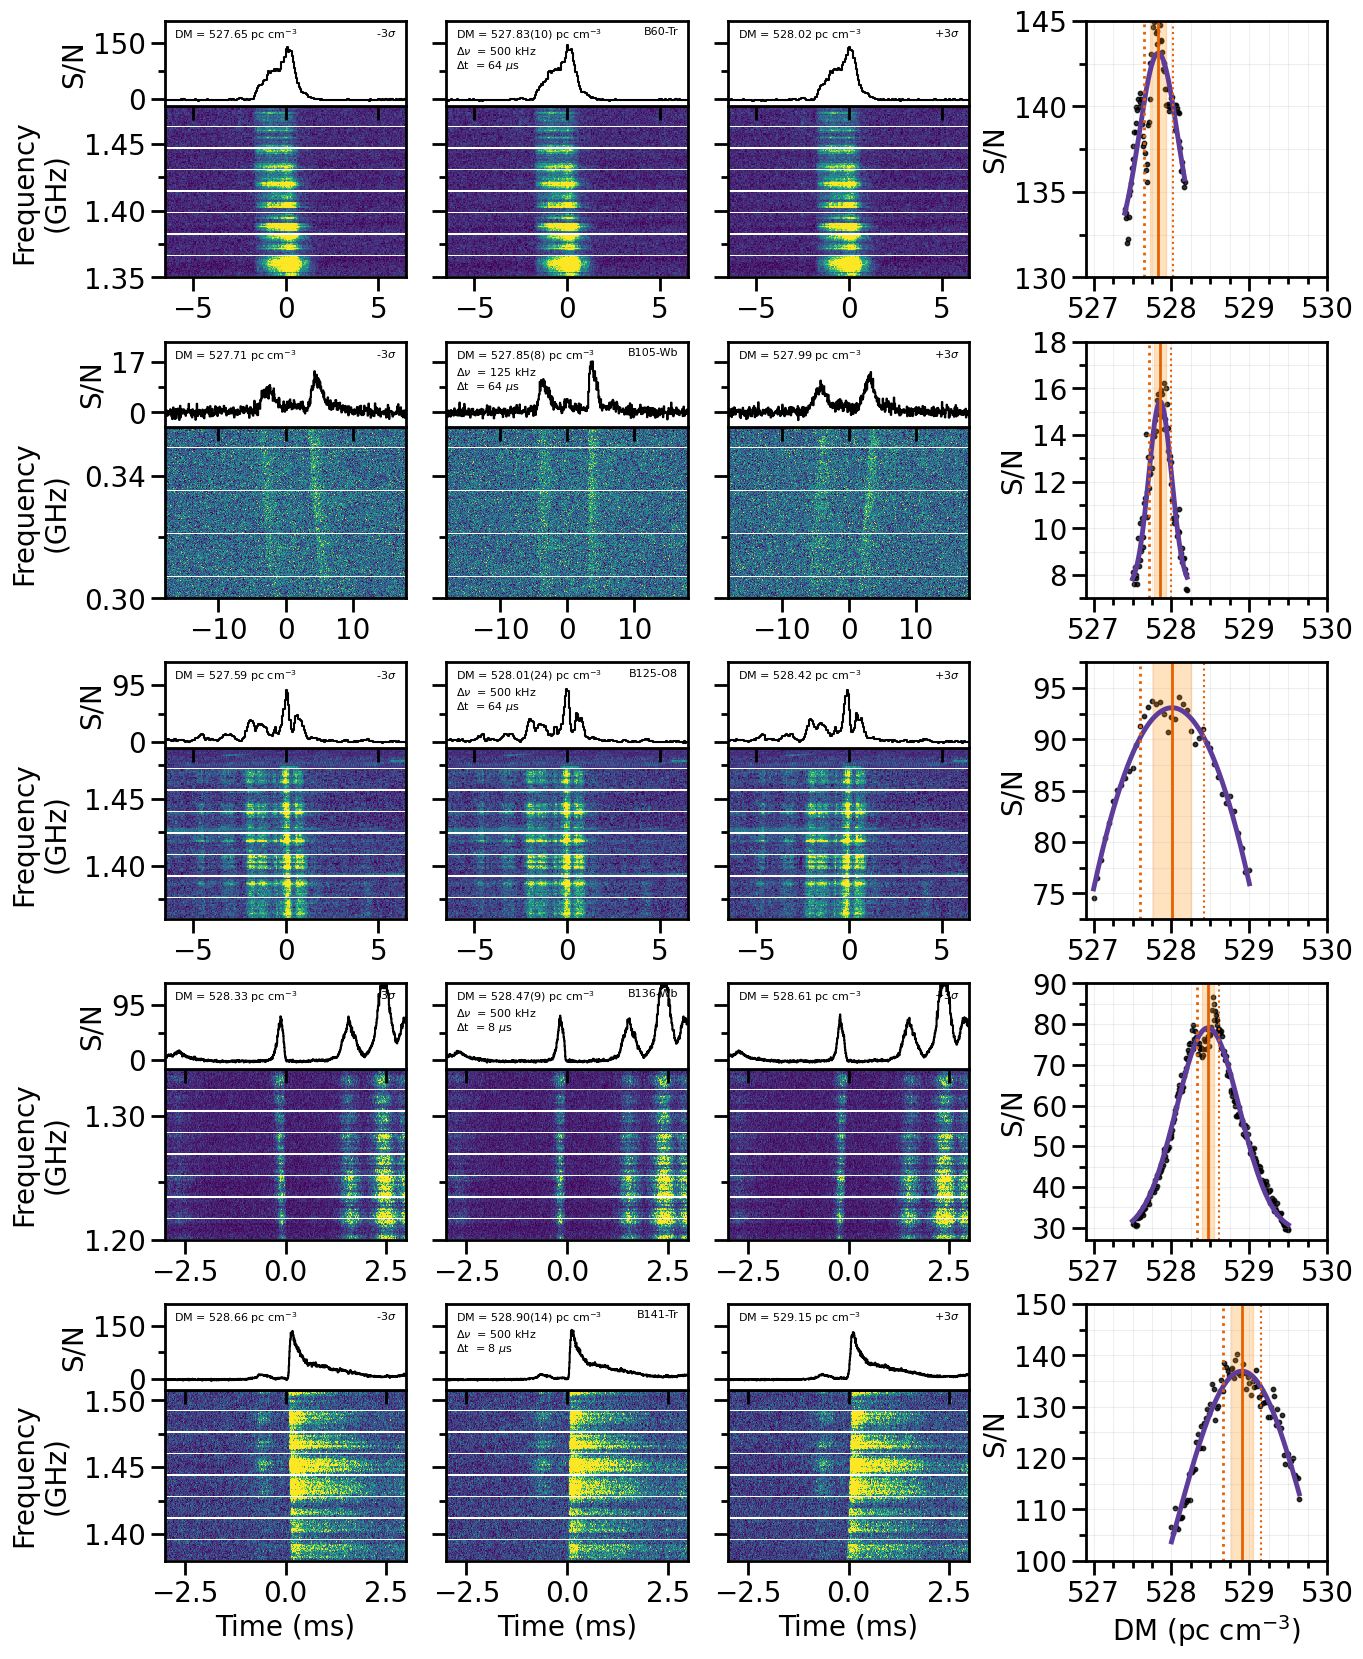

In [12]:
def scalable_waterfall_plot(fig_size=(15, 20)):
    """
    Generates a 4-row, 4-column grid with a variable column spacing.
    
    - First 3 columns contain time series (top) and dynamic spectra (bottom).
    - Column 4 is an empty gap for extra spacing.
    - Column 5 contains S/N vs DM scatter plots.
    - The layout is fixed to 4 rows.
    """

    #Load in the dictionaries to loop over
    burst_dict = burst_database()
    csv_dict = csv_database()
    
    num_rows = 5  # Fixed number of rows
    num_cols = 5  # Including the artificial gap column
    fig = plt.figure(figsize=fig_size)
    
    # Width ratios: [1, 1, 1, gap (0.15), DM-S/N column (1)]
    outer_spec = gridspec.GridSpec(num_rows, num_cols, 
                                   figure=fig, 
                                   width_ratios=[1, 1, 1, 0.15, 1], \
                                   height_ratios=[1] * num_rows, 
                                   wspace=0.2, hspace=0.25)


    for i, burst_db_val in enumerate(burst_dict):

        #An not so easy readable command to find which panel we have to draw in: (0,0) , (2,0) etc
        row, col = divmod(i, 3)
        
        print(f"col:{col}, row:{row}")
        print(burst_db_val)
        if row >= num_rows:  # Skip extra bursts beyond 4 rows
            break

        # Adjust for the artificial gap column
        true_col = col if col < 3 else col + 1  # Shift columns after the 3rd
        
        # Nested gridspec for each burst (time series:dynamic spectrum = 1:2)
        inner_spec = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_spec[row, true_col], height_ratios=[1, 2], hspace=0)

        ########
        #Loading in the burst data
        stokes_i, stokes_i_normprof, x_grid, new_quantiles, extent, tsamp, fsamp = load_fil(burst_db_val["file"], 
                                                                                            burst_tstamp=burst_db_val["burst_tstamp"],\
                                                                                            downsamp_t=burst_db_val["tdown"],\
                                                                                            downsamp_f=burst_db_val["fdown"])

        DM_value = burst_db_val["dm"]
        window_ms = burst_db_val["xwin"]
        maxSN = burst_db_val["ylim_t"]
        minSN = burst_db_val["ylim_b"]
        burst_id = burst_db_val["burst_id"]
                       
        # Dynamic spectrum panel
        ax_bottom = fig.add_subplot(inner_spec[1])
        ax_bottom.imshow(stokes_i, aspect='auto', interpolation='None', \
                         extent=extent, vmin=new_quantiles[0], vmax=new_quantiles[1])
        
        ax_bottom.set_xlim(-window_ms,window_ms)
        ax_bottom.yaxis.set_major_locator(ticker.LinearLocator(4))

        ax_top = fig.add_subplot(inner_spec[0], sharex=ax_bottom)
        ax_top.plot(x_grid, stokes_i_normprof, color='black', drawstyle='steps-post')
        ax_top.tick_params(labelbottom=False, labelsize=20)

        #Create space for the text in the plot
        window_sn = 1.4 * maxSN
        print("S/N range:", minSN, window_sn)
        ax_top.yaxis.set_major_locator(ticker.FixedLocator([0, maxSN]))
        ax_top.set_ylim(minSN,window_sn)

        # Add a minor tick at half of maxSN
        half_maxSN = maxSN / 2
        ax_top.yaxis.set_minor_locator(ticker.FixedLocator([half_maxSN]))

        ###### 
        #Writing in the boxes
        if col == 1:
            ax_top.text(0.04, 0.93, fr"DM = {DM_value}" + r" pc cm$^{-3}$" + "\n" + \
                        fr"$\Delta \nu$  = {(fsamp*1e3):.0f} kHz " + "\n" + \
                        fr"$\Delta$t  = {(tsamp*1e6):.0f} $\mu$s",  \
                        fontsize=8, va='top', ha='left', transform=ax_top.transAxes)

            ax_top.text(0.96, 0.93, f"{burst_id}", transform=ax_top.transAxes, fontsize=8, va='top', ha='right')

        elif col == 0:
            ax_top.text(0.96, 0.93, rf"-3$\sigma$", transform=ax_top.transAxes, fontsize=8, va='top', ha='right')
            ax_top.text(0.04, 0.93, fr"DM = {DM_value:.2f}" + r" pc cm$^{-3}$", \
                        fontsize=8, va='top', ha='left', transform=ax_top.transAxes)  
            
        elif col == 2:
            ax_top.text(0.96, 0.93, rf"+3$\sigma$", transform=ax_top.transAxes, fontsize=8, va='top', ha='right')
            ax_top.text(0.04, 0.93, fr"DM = {DM_value:.2f}" + r" pc cm$^{-3}$", \
                        fontsize=8, va='top', ha='left', transform=ax_top.transAxes)  

            
        #    ax1.text(0.04, 0.93, fr"$\Delta$t  = {(tsamp*1e6):.0f} $\mu$s" + "\n" + fr"$\Delta \nu$  = {(fsamp*1e3):.0f} kHz " + "\n" + \
        #     fr"DM = {DM:.3f}"+ r" pc cm$^{-3}$", transform=ax1.transAxes, fontsize=16, va='top', ha='left')

        # Enable Y-ticks for the leftmost and rightmost columns
        if col == 0 or true_col == 4:
            ax_top.tick_params(labelleft=True, labelsize=20)
            ax_bottom.tick_params(labelleft=True, labelsize=20)
        else:
            ax_top.tick_params(labelleft=False)
            ax_bottom.tick_params(labelleft=False)

        # Enable X-ticks for all panels with dynamic spectra
        ax_bottom.tick_params(labelbottom=True, labelsize=20)

        # Y-tick / frequency axis logic based on burst_id
        if "B105" in burst_id:
            ax_bottom.set_yticks([340, 300], ["", ""])
            ax_bottom.yaxis.set_minor_locator(ticker.FixedLocator([320]))
            if col == 0:
                ax_bottom.set_ylabel('Frequency\n(GHz)', fontsize=20, labelpad=10.0)
                ax_top.set_ylabel('S/N', fontsize=20)
                ax_bottom.set_yticks([340, 300], ["0.34", "0.30"])

        elif "B141" in burst_id:
            ax_bottom.set_yticks([1400, 1450, 1500], ["", "", ""])
            ax_bottom.yaxis.set_minor_locator(ticker.FixedLocator([1425, 1475]))
            if col == 0:
                ax_bottom.set_ylabel('Frequency\n(GHz)', fontsize=20, labelpad=10.0)
                ax_top.set_ylabel('S/N', fontsize=20)
                ax_bottom.set_yticks([1400, 1450, 1500], ["1.40", "1.45", "1.50"])
                
        elif "Tr" in burst_id:
            ax_bottom.set_yticks([1350, 1400, 1450], ["", "", ""])
            ax_bottom.yaxis.set_minor_locator(ticker.FixedLocator([1375, 1425]))
            if col == 0:
                ax_bottom.set_ylabel('Frequency\n(GHz)', fontsize=20, labelpad=10.0)
                ax_top.set_ylabel('S/N', fontsize=20)
                ax_bottom.set_yticks([1350, 1400, 1450], ["1.35", "1.40", "1.45"])
                
        elif "O8" in burst_id:
            ax_bottom.set_yticks([1400, 1450], ["", ""])
            ax_bottom.yaxis.set_minor_locator(ticker.FixedLocator([1375,1425, 1475]))
            if col == 0:
                ax_bottom.set_ylabel('Frequency\n(GHz)', fontsize=20, labelpad=10.0)
                ax_top.set_ylabel('S/N', fontsize=20)
                ax_bottom.set_yticks([1400, 1450], ["1.40", "1.45"])
                
        elif "Wb" in burst_id:
            ax_bottom.set_yticks([1300, 1207], ["", ""])
            ax_bottom.yaxis.set_minor_locator(ticker.FixedLocator([1250]))
            if col == 0:
                ax_bottom.set_ylabel('Frequency\n(GHz)', fontsize=20, labelpad=10.0)
                ax_top.set_ylabel('S/N', fontsize=20)
                ax_bottom.set_yticks([1300, 1207], ["1.30", "1.20"])
                
        # ax_bottom.set_yticks([1300, 1207], ["", ""])  # Convert to GHz
        # ax_bottom.yaxis.set_minor_locator(ticker.FixedLocator([1250]))
        # # Label axes with larger font size
        # if col == 0:
        #     ax_bottom.set_ylabel('Frequency\n(GHz)', fontsize=20, labelpad=10.0)
        #     ax_top.set_ylabel('S/N', fontsize=20)

        #     # Manually set GHz tick positions (assuming they are in MHz)
        #     ax_bottom.set_yticks([1300, 1207], ["1.3", "1.2"])  # Set tick positions in MHz 
        #     #we smuggle 7 MHz, but nobody is going to care and notice
        #     # ax_bottom.set_yticklabels([1.3, 1.2])  # Convert to GHz

        if row == num_rows - 1 and col in [0, 1, 2]:
            ax_bottom.set_xlabel('Time (ms)', fontsize=20)

    # S/N vs DM scatter plots in the last column - number 4
    for row, csv_dict_val in enumerate(csv_dict):
        if row == 0:
            ax_sn_master = fig.add_subplot(outer_spec[row, 4])  # First subplot as master
            ax_sn = ax_sn_master
        else:
            ax_sn = fig.add_subplot(outer_spec[row, 4], sharex=ax_sn_master)  # Share x-axis with the first subplot
            
        dm_range, sn_range, dm_space, poptc, best_dm, sigma_err, sigma_3_err = load_csv(csv=csv_dict_val["file"],\
                                                                             p0_guess=csv_dict_val["p0_guess"])
        
        ax_sn.scatter(dm_range, sn_range,color='k',s=10, alpha=0.8)
        
        ax_sn.plot(dm_space,gaus(dm_space,*poptc),color='#5e3c99',lw=3.5)
        ax_sn.axvline(best_dm,color="#e66101", lw=2)
        ax_sn.axvline(best_dm-sigma_3_err,color="#e66101", lw=2, ls="dotted")
        ax_sn.axvline(best_dm+sigma_3_err,color="#e66101", lw=1.5, ls="dotted")
        ax_sn.axvspan(xmin=best_dm-sigma_err, xmax=best_dm+sigma_err, ymin=0, ymax=1, color='darkorange', alpha=0.25)

        ax_sn.grid(which="both", alpha=0.2)
        ax_sn.yaxis.set_major_locator(ticker.MultipleLocator(csv_dict_val["major_yticks_label"]))
        ax_sn.yaxis.set_minor_locator(ticker.MultipleLocator(csv_dict_val["minor_yticks_space"]))
        ax_sn.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))
        ax_sn.xaxis.set_major_locator(ticker.MultipleLocator(1.0))

        ax_sn.set_ylim(csv_dict_val["ylim_b"],csv_dict_val["ylim_t"]) # Set fixed limits per curve
        ax_sn.set_xlim(526.9, 530.0)  # Set fixed x-axis range
        
        #Set the labels
        ax_sn.set_xlabel('DM (pc cm$^{-3}$)' if row == num_rows - 1 else '', fontsize=20)
        ax_sn.set_ylabel('S/N', fontsize=20)

        # Ensure ticks on rightmost column
        ax_sn.tick_params(labelleft=True, labelbottom=True, labelsize=20)

    update_spines(fig, tick_labelsize=20)

    plot_name = "dynamic_matrix_r147_v2"
    fig.savefig(plot_name + ".pdf", dpi=300, bbox_inches='tight')
    
    fig.savefig(plot_name + ".png", facecolor='white', \
            transparent=False, format = 'png',bbox_inches='tight', dpi=300)

    plt.show()
    
scalable_waterfall_plot()